In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_excel("AI.xlsx")

# Compute AI
df["AI"] = df["apoptosis"] / (df["apoptosis"] + df["survival"])

# Save as CSV
df.to_csv("AI_with_values.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [3]:
import pandas as pd

# Load
df = pd.read_csv("Final_Tokens_Dataset.csv")

# Drop chimp
df = df.drop(columns=["Tokens_Chimp"])

print(df.head())

  gene_name  Tokens_Normal  Tokens_Tumor
0      AKT1              2             3
1     APAF1              1             1
2       ATM              1             1
3       ATR              1             1
4       BAD              1             2


In [4]:
print("helo world")

helo world


In [5]:
# Set gene as index
df = df.set_index("gene_name")

# Transpose
df_t = df.T

# Add case names
df_t["case"] = ["normal", "cancer"]

# Move case to front
df_t = df_t.reset_index(drop=True)
cols = ["case"] + [col for col in df_t.columns if col != "case"]
df_t = df_t[cols]

print(df_t.head())

gene_name    case  AKT1  APAF1  ATM  ATR  BAD  BAK1  BAX  BCL2  BCL2L1  ...  \
0          normal     2      1    1    1    1     2    3     1       4  ...   
1          cancer     3      1    1    1    2     4    4     1       6  ...   

gene_name  FAS  MAPK1  MAPK3  MDM2  NFKB1  PIK3CA  RELA  TNFRSF10B  TP53  XIAP  
0            1      4      4     1      2       1     3          3     2     2  
1            2      6      5     2      3       1     5          3     3     4  

[2 rows x 31 columns]


In [6]:
# Base normal row
normal = df_t[df_t["case"] == "normal"].copy()

# Scenario 1 — Survival activation
s1 = normal.copy()
s1["case"] = "S1"
s1["AKT1"] = 5
s1["BCL2"] = 4

# Scenario 2 — Apoptosis suppression
s2 = normal.copy()
s2["case"] = "S2"
s2["TP53"] = 0
s2["BAX"] = 1

# Scenario 3 — Caspase suppression
s3 = normal.copy()
s3["case"] = "S3"
s3["CASP3"] = 0
s3["CASP8"] = 0

# Scenario 4 — TP53 activation
s4 = normal.copy()
s4["case"] = "S4"
s4["TP53"] = 5

# Scenario 5 — Mitochondrial push
s5 = normal.copy()
s5["case"] = "S5"
s5["BAX"] = 5
s5["BAK1"] = 4

# Scenario 6 — Caspase boost
s6 = normal.copy()
s6["case"] = "S6"
s6["CASP3"] = 5
s6["CASP6"] = 4

# Scenario 7 — BCL2 inhibition
s7 = normal.copy()
s7["case"] = "S7"
s7["BCL2"] = 0

# Scenario 8 — XIAP inhibition (VERY IMPORTANT ONE)
s8 = normal.copy()
s8["case"] = "S8"
s8["XIAP"] = 0

# Scenario 9 — Balanced therapy
s9 = normal.copy()
s9["case"] = "S9"
s9["BCL2"] = 0
s9["TP53"] = 5
s9["BAX"] = 5

# Scenario 10 — Strong intervention
s10 = normal.copy()
s10["case"] = "S10"
s10["AKT1"] = 0
s10["BCL2"] = 0
s10["TP53"] = 5
s10["CASP3"] = 5

# Combine all
df_final = pd.concat([df_t, s1, s2, s3, s4, s5, s6, s7, s8, s9, s10], ignore_index=True)

print(df_final.head(15))

gene_name    case  AKT1  APAF1  ATM  ATR  BAD  BAK1  BAX  BCL2  BCL2L1  ...  \
0          normal     2      1    1    1    1     2    3     1       4  ...   
1          cancer     3      1    1    1    2     4    4     1       6  ...   
2              S1     5      1    1    1    1     2    3     4       4  ...   
3              S2     2      1    1    1    1     2    1     1       4  ...   
4              S3     2      1    1    1    1     2    3     1       4  ...   
5              S4     2      1    1    1    1     2    3     1       4  ...   
6              S5     2      1    1    1    1     4    5     1       4  ...   
7              S6     2      1    1    1    1     2    3     1       4  ...   
8              S7     2      1    1    1    1     2    3     0       4  ...   
9              S8     2      1    1    1    1     2    3     1       4  ...   
10             S9     2      1    1    1    1     2    5     0       4  ...   
11            S10     0      1    1    1    1     2 

In [7]:
ai_df = pd.read_csv("AI_with_values.csv")

df_final = df_final.merge(ai_df[["case", "AI"]], on="case", how="left")

In [8]:
df_final.to_csv("AI_gene_dataset.csv", index=False)

In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# ==============================
# 1. Load dataset
# ==============================
df = pd.read_csv(r"C:\Users\aatif\Downloads\ml part in project\AI_gene_dataset.csv")

# Clean column names (important)
df.columns = df.columns.str.strip()

print("Columns in dataset:\n", df.columns)

Columns in dataset:
 Index(['case', 'AKT1', 'APAF1', 'ATM', 'ATR', 'BAD', 'BAK1', 'BAX', 'BCL2',
       'BCL2L1', 'BID', 'CASP10', 'CASP3', 'CASP6', 'CASP7', 'CASP8', 'CASP9',
       'CDKN1A', 'CYCS', 'DIABLO', 'FADD', 'FAS', 'MAPK1', 'MAPK3', 'MDM2',
       'NFKB1', 'PIK3CA', 'RELA', 'TNFRSF10B', 'TP53', 'XIAP', 'AI'],
      dtype='object')


In [10]:
if "AI_x" in df.columns and "AI_y" in df.columns:
    df["AI"] = df["AI_x"]   # keep one
    df = df.drop(columns=["AI_x", "AI_y"])

if "AI" not in df.columns:
    print("AI column missing — computing manually...")
    df["AI"] = df["apoptosis"] / (df["apoptosis"] + df["survival"])
    
X = df.drop(["case", "AI"], axis=1)
y = df["AI"]

# Ensure all values are numeric
X = X.apply(pd.to_numeric)


In [11]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

RandomForestRegressor(random_state=42)

In [12]:
# 6. Predictions & evaluation
y_pred = model.predict(X)
print("\nModel Performance:")
print("R2 Score:", r2_score(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))



Model Performance:
R2 Score: 0.847987863807504
MSE: 0.0020946157499306165


In [13]:
importance_df = pd.DataFrame({
    "Gene": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Genes:\n")
print(importance_df.head(10))


Top Important Genes:

      Gene  Importance
29    XIAP    0.553646
6      BAX    0.278312
5     BAK1    0.039476
11   CASP3    0.022001
16  CDKN1A    0.021950
7     BCL2    0.014558
0     AKT1    0.013567
14   CASP8    0.010866
28    TP53    0.010780
15   CASP9    0.008641


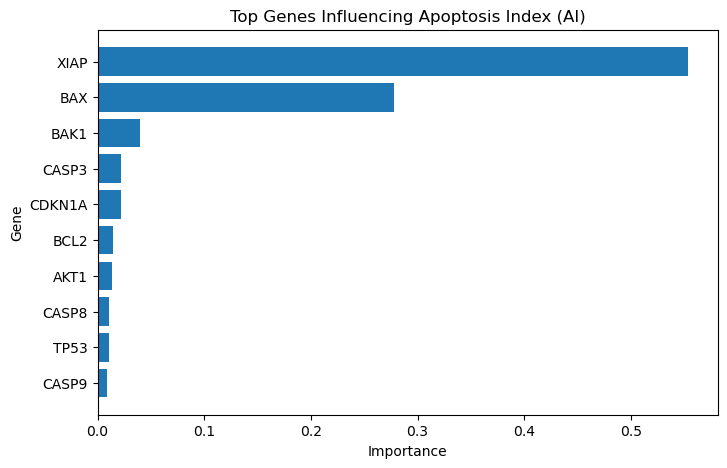

In [14]:
top_n = 10
top_features = importance_df.head(top_n)

plt.figure(figsize=(8,5))
plt.barh(top_features["Gene"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Gene")
plt.title("Top Genes Influencing Apoptosis Index (AI)")
plt.gca().invert_yaxis()
plt.show()

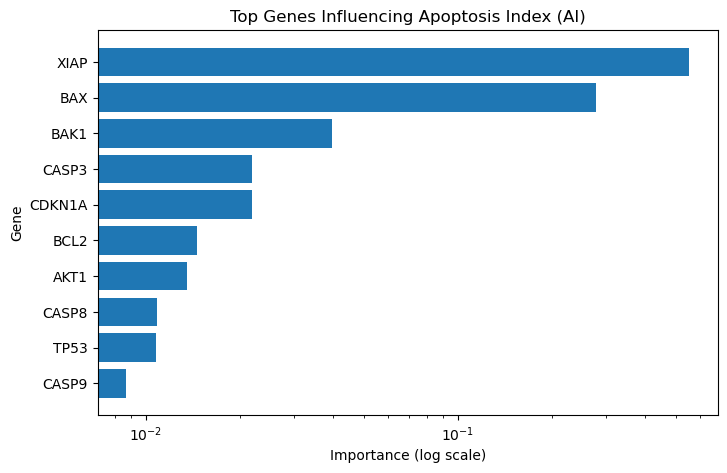

In [19]:
import matplotlib.pyplot as plt

top_n = 10
top_features = importance_df.head(top_n)

plt.figure(figsize=(8,5))
plt.barh(top_features["Gene"], top_features["Importance"])

plt.xscale('log')  # 🔥 THIS LINE

plt.xlabel("Importance (log scale)")
plt.ylabel("Gene")
plt.title("Top Genes Influencing Apoptosis Index (AI)")
plt.gca().invert_yaxis()

plt.show()

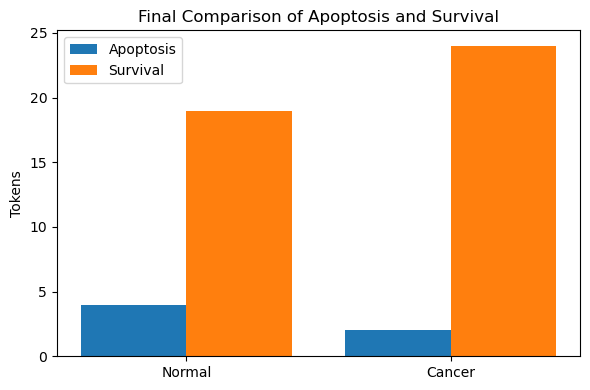

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Replace with YOUR values
normal_apoptosis = 4
normal_survival = 19

cancer_apoptosis = 2
cancer_survival = 24

labels = ["Normal", "Cancer"]

apoptosis = [normal_apoptosis, cancer_apoptosis]
survival = [normal_survival, cancer_survival]

x = np.arange(len(labels))

plt.figure(figsize=(6,4))
plt.bar(x - 0.2, apoptosis, width=0.4, label="Apoptosis")
plt.bar(x + 0.2, survival, width=0.4, label="Survival")

plt.xticks(x, labels)
plt.ylabel("Tokens")
plt.title("Final Comparison of Apoptosis and Survival")
plt.legend()

plt.tight_layout()
plt.savefig("figure_3_8.png", dpi=300)
plt.show()

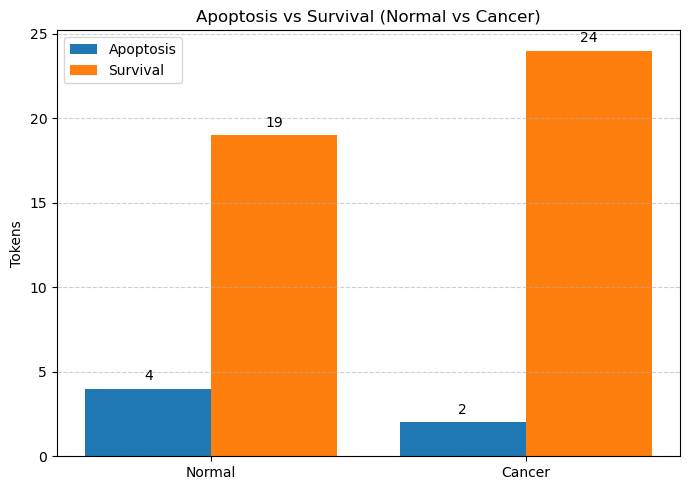

In [16]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Normal", "Cancer"]
apoptosis = [4, 2]
survival = [19, 24]

x = np.arange(len(labels))

plt.figure(figsize=(7,5))
bars1 = plt.bar(x - 0.2, apoptosis, width=0.4, label="Apoptosis")
bars2 = plt.bar(x + 0.2, survival, width=0.4, label="Survival")

# Add values on top
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height()}',
                 ha='center')

plt.xticks(x, labels)
plt.ylabel("Tokens")
plt.title("Apoptosis vs Survival (Normal vs Cancer)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("figure_3_8.png", dpi=300)
plt.show()

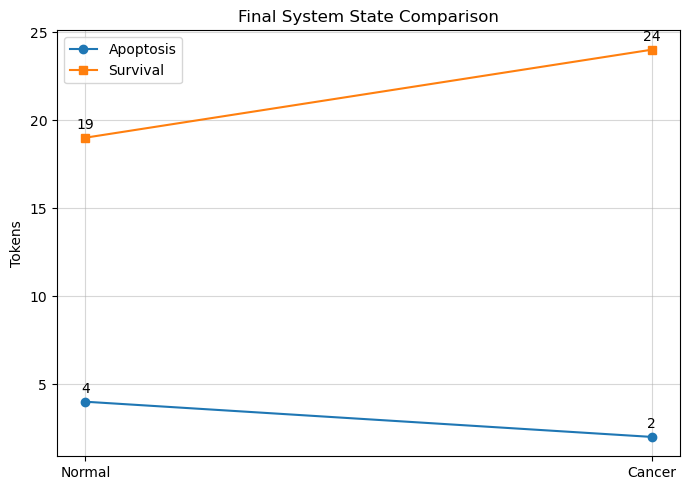

In [17]:
plt.figure(figsize=(7,5))

plt.plot(labels, apoptosis, marker='o', label="Apoptosis")
plt.plot(labels, survival, marker='s', label="Survival")

for i in range(len(labels)):
    plt.text(labels[i], apoptosis[i]+0.5, str(apoptosis[i]), ha='center')
    plt.text(labels[i], survival[i]+0.5, str(survival[i]), ha='center')

plt.ylabel("Tokens")
plt.title("Final System State Comparison")
plt.legend()
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

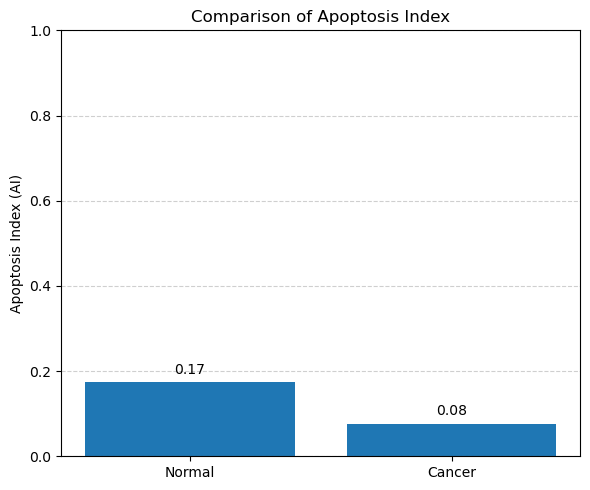

In [18]:
import matplotlib.pyplot as plt

labels = ["Normal", "Cancer"]

AI = [
    4/(4+19),
    2/(2+24)
]

plt.figure(figsize=(6,5))
plt.bar(labels, AI)

for i in range(len(labels)):
    plt.text(i, AI[i] + 0.02, f"{AI[i]:.2f}", ha='center')

plt.ylabel("Apoptosis Index (AI)")
plt.title("Comparison of Apoptosis Index")

plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()